# Overlay UMAP Backbone Inspection

Compact paper-oriented overlay plots for cross-dataset UMAP. Metadata panels use one shared circular marker for both datasets; a separate dataset panel colors EMBED and VinDr directly.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn import decomposition
from sklearn.preprocessing import normalize

import sys
from pathlib import Path
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'src').exists() and (REPO_ROOT.parent / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from mammo_benchmark.config import MODEL_SPECS

sns.set_theme(style='white', palette='deep', context='paper')

FIXED_HUE_ORDERS = {
    'breast_birads': ['BI-RADS 1', 'BI-RADS 2', 'BI-RADS 3', 'BI-RADS 4', 'BI-RADS 5'],
    'breast_birads_display': ['BI-RADS 1', 'BI-RADS 2', 'BI-RADS 3', 'BI-RADS 4', 'BI-RADS 5'],
    'breast_density': ['DENSITY A', 'DENSITY B', 'DENSITY C', 'DENSITY D'],
    'density': ['A', 'B', 'C', 'D'],
    'view_position': ['CC', 'MLO'],
    'ViewPosition': ['CC', 'MLO'],
    'laterality': ['L', 'R'],
    'ImageLateralityFinal': ['L', 'R'],
    'Dataset': ['EMBED', 'VinDr'],
    'manufacturer_group': ['SIEMENS', 'Planmed', 'IMS', 'HOLOGIC', 'GE', 'FUJIFILM'],
}

ATTR_TITLES = {
    'Dataset': 'Dataset',
    'breast_birads': 'BI-RADS',
    'breast_birads_display': 'BI-RADS',
    'breast_density': 'Breast density',
    'view_position': 'View',
    'manufacturer_group': 'Manufacturer',
}

ATTR_SLUGS = {
    'Dataset': 'dataset',
    'breast_birads_display': 'breast_birads',
    'manufacturer_group': 'manufacturer',
}

CUSTOM_PALETTES = {
    'Dataset': {
        'EMBED': '#1F4E79',
        'VinDr': '#B04A3F',
    },
}

PLOT_RANDOM_SEED = 42


def relpath(path):
    path = Path(path)
    try:
        return path.relative_to(REPO_ROOT)
    except ValueError:
        return path


def require_file(path, hint):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(f'Missing required file: {path}\n{hint}')
    return path


def attr_title(attr):
    return ATTR_TITLES.get(attr, attr)


def attr_slug(attr):
    return ATTR_SLUGS.get(attr, attr)


def normalize_birads_labels(values):
    return values.astype('string').str.replace(r'\s+\([A-Z]\)$', '', regex=True)


def add_display_columns(data):
    if 'breast_birads' in data.columns:
        data['breast_birads_display'] = normalize_birads_labels(data['breast_birads'])
    return data


def hue_style(data, attr):
    counts = data[attr].dropna().value_counts()
    if counts.empty:
        return [], {}

    fixed_order = FIXED_HUE_ORDERS.get(attr)
    if fixed_order is None:
        palette_levels = counts.index.tolist()
        hue_order = palette_levels
    else:
        extras = [v for v in counts.index if v not in fixed_order]
        palette_levels = fixed_order + extras
        hue_order = [v for v in palette_levels if v in counts.index]

    custom_palette = CUSTOM_PALETTES.get(attr)
    if custom_palette is None:
        palette = dict(zip(palette_levels, sns.color_palette('deep', n_colors=len(palette_levels))))
    else:
        fallback = sns.color_palette('deep', n_colors=len(palette_levels))
        palette = {
            level: custom_palette.get(level, fallback[idx])
            for idx, level in enumerate(palette_levels)
        }
    return hue_order, palette

In [2]:
# ---- Backbone ----
backbone_key = os.environ.get('BACKBONE_KEY', 'dinov3_vitb')

# ---- Extractor output ----
inspection_output_root = Path(os.environ.get('INSPECTION_OUTPUT_ROOT', REPO_ROOT / 'outputs' / 'inspection_embeddings'))
feature_mode = 'native'
inspection_splits = ['Train', 'Eval', 'Test']

# ---- Pre-selected plotting samples ----
dataset_specs = {
    'vindr': {
        'dataset_name': 'VinDr-Mammo-breast',
        'display_name': 'VinDr',
        'sample_csv': REPO_ROOT / 'data' / 'inspection_samples' / 'vindr_inspection_sample.csv',
    },
    'embed': {
        'dataset_name': 'EMBED',
        'display_name': 'EMBED',
        'sample_csv': REPO_ROOT / 'data' / 'inspection_samples' / 'embed_inspection_sample.csv',
    },
}

# ---- UMAP + paper style ----
embedding_norm = 'l2'
plot_style_tag = f'overlay-umap-cosine-paper-{embedding_norm}-singlemarker-nokde'
rasterized_scatter = True

umap_n_pca_components = 50
umap_n_neighbors = 80
umap_min_dist = 0.35
umap_random_state = 42
umap_metric = 'cosine'

# All UMAP panels now use one shared filled circular marker. Dataset identity is
# visualized as its own colored panel instead of via marker shape.
point_style = dict(marker='o', s=8.4, alpha=0.50, linewidths=0, zorder=1)

if backbone_key not in MODEL_SPECS:
    raise KeyError(f'Unknown backbone: {backbone_key}. Available: {list(MODEL_SPECS)}')

spec = MODEL_SPECS[backbone_key]
splits_tag = '+'.join(inspection_splits)
overlay_out_dir = inspection_output_root / backbone_key / 'plots' / f'{feature_mode}-{splits_tag}-{plot_style_tag}'
overlay_out_dir.mkdir(parents=True, exist_ok=True)

print(f'Backbone: {spec["display_name"]}')
print(f'Embedding root: {relpath(inspection_output_root / backbone_key)}')
print(f'Overlay output: {relpath(overlay_out_dir)}')
print(f'Feature mode: {feature_mode} | splits: {inspection_splits}')

Backbone: DINOv3 (ViT-B)
Embedding root: outputs/inspection_embeddings/dinov3_vitb
Overlay output: outputs/inspection_embeddings/dinov3_vitb/plots/native-Train+Eval+Test-overlay-umap-cosine-paper-l2-singlemarker-nokde
Feature mode: native | splits: ['Train', 'Eval', 'Test']


In [3]:
def path_tag(value):
    return ''.join(ch if ch.isalnum() or ch in ('-', '_') else '-' for ch in value).strip('-')


def embedding_paths(dataset_cfg):
    base_dir = inspection_output_root / backbone_key
    dataset_tag = path_tag(dataset_cfg['dataset_name'])
    return (
        base_dir / f'embeddings_{dataset_tag}_{feature_mode}.npy',
        base_dir / f'metadata_{dataset_tag}.parquet',
    )


def extractor_hint(dataset_cfg):
    splits_arg = ','.join(inspection_splits)
    return (
        'Run e.g.: '
        f'DATASETS={dataset_cfg["dataset_name"]} MODELS={backbone_key} '
        f'SPLITS={splits_arg} FEATURE_MODE={feature_mode} '
        f'python scripts/extract_inspection_embeddings.py --datasets {dataset_cfg["dataset_name"]} --models {backbone_key} --splits {splits_arg} --feature_mode {feature_mode} --output_root {inspection_output_root}'
    )


def canonical_birads(values):
    return values.astype('string').str.replace('Bi-Rads', 'BI-RADS', regex=False)


def canonical_density(values):
    return values.astype('string').str.replace('Level ', 'DENSITY ', regex=False)


def canonical_manufacturer_group(values):
    return values.astype('string').replace({
        'IMS s.r.l.': 'IMS',
        'IMS GIOTTO S.p.A.': 'IMS',
        'GE MEDICAL SYSTEMS': 'GE',
        'GE HEALTHCARE': 'GE',
        'HOLOGIC, Inc.': 'HOLOGIC',
        'FUJIFILM Corporation': 'FUJIFILM',
    })


def load_dataset_embeddings(dataset_key, dataset_cfg):
    emb_path, out_meta_path = embedding_paths(dataset_cfg)
    emb_path = require_file(emb_path, extractor_hint(dataset_cfg))
    out_meta_path = require_file(out_meta_path, extractor_hint(dataset_cfg))

    emb = np.load(emb_path)
    out_meta = pd.read_parquet(out_meta_path)
    if len(emb) != len(out_meta):
        raise ValueError(
            f'{dataset_key}: embedding/metadata row mismatch: '
            f'{len(emb)} embeddings vs {len(out_meta)} metadata rows.'
        )

    expected_splits = set(inspection_splits)
    observed_splits = set(out_meta['split'].astype(str).unique())
    if observed_splits != expected_splits:
        raise ValueError(
            f'{dataset_key}: embedding file has splits {sorted(observed_splits)}, '
            f'but notebook expects {sorted(expected_splits)}.'
        )

    feature_cols = [f'f{i}' for i in range(emb.shape[1])]
    df_emb = pd.DataFrame(emb, columns=feature_cols)
    data = pd.concat([df_emb, out_meta.reset_index(drop=True)], axis=1)
    return data, feature_cols


def standardize_cross_attrs(data):
    data = data.copy()
    data['study_id'] = data['patient_id'].astype(str)
    data['image_id'] = data['sample_name'].astype(str)
    data['laterality'] = data['side'].astype(str)
    data['breast_birads'] = canonical_birads(data['bi_rads'])
    data['breast_density'] = canonical_density(data['density'])
    data['view_position'] = data['view'].astype(str)
    data['manufacturer_group'] = canonical_manufacturer_group(data['manufacturer'])
    return add_display_columns(data)


def load_cross_full(dataset_key, display_name=None):
    dataset_cfg = dataset_specs[dataset_key]
    display_name = display_name or dataset_cfg['display_name']
    sample_path = require_file(dataset_cfg['sample_csv'], 'Create the plotting sample with resample_inspection.ipynb first.')

    data, feature_cols = load_dataset_embeddings(dataset_key, dataset_cfg)
    data = standardize_cross_attrs(data)
    data['Dataset'] = display_name

    sample_ids = pd.read_csv(sample_path, usecols=['study_id', 'image_id'], low_memory=False)
    sample_ids['study_id'] = sample_ids['study_id'].astype(str)
    sample_ids['image_id'] = sample_ids['image_id'].astype(str)
    sample_ids = sample_ids.drop_duplicates()
    sample_ids['_plot_sample'] = True

    data = data.merge(sample_ids, on=['study_id', 'image_id'], how='left')
    data['_plot_sample'] = data['_plot_sample'].fillna(False).astype(bool)
    print(f'{display_name}: {len(data)} full images | {data["_plot_sample"].sum()} selected for plotting')
    return data, feature_cols


In [4]:
vindr_full, feature_cols_vindr = load_cross_full('vindr')
embed_full, feature_cols_embed = load_cross_full('embed')
if len(feature_cols_vindr) != len(feature_cols_embed):
    raise ValueError(
        f'Feature mismatch: VinDr has {len(feature_cols_vindr)} dims, '
        f'EMBED has {len(feature_cols_embed)} dims'
    )

cross_feature_cols = feature_cols_vindr
df_cross_full = pd.concat([vindr_full, embed_full], ignore_index=True)
df_cross = df_cross_full[df_cross_full['_plot_sample']].copy().reset_index(drop=True)
if df_cross.empty:
    raise ValueError('No selected cross-dataset samples matched the full embedding tables.')

print(f'Cross-dataset sample for plotting: {len(df_cross)} images')
print(df_cross['Dataset'].value_counts().to_string())

emb_cross = df_cross[cross_feature_cols].to_numpy(dtype=np.float32)
if embedding_norm == 'l2':
    emb_cross = normalize(emb_cross, norm='l2', copy=False)
elif embedding_norm != 'none':
    raise ValueError(f'Unknown embedding_norm: {embedding_norm}')
print(f'Embedding normalization: {embedding_norm}')

pca_cross = decomposition.PCA(n_components=0.99, whiten=False)
emb_cross_pca = pca_cross.fit_transform(emb_cross)
n_umap_pcs = min(umap_n_pca_components, emb_cross_pca.shape[1])
print(f'Joint PCA on selected sample: {emb_cross.shape[0]} images, {emb_cross.shape[1]} -> {emb_cross_pca.shape[1]} components')
print(f'Running joint UMAP on selected-sample PCA data: {emb_cross_pca.shape[0]} images x {n_umap_pcs} PCs')

try:
    import umap.umap_ as umap
except ImportError as exc:
    raise ImportError('UMAP requested but umap-learn is not installed in this notebook kernel.') from exc

emb_cross_umap = umap.UMAP(
    n_components=2,
    n_neighbors=umap_n_neighbors,
    min_dist=umap_min_dist,
    metric=umap_metric,
    random_state=umap_random_state,
).fit_transform(emb_cross_pca[:, :n_umap_pcs].astype(np.float32, copy=False))

df_cross['UMAP 1'] = emb_cross_umap[:, 0]
df_cross['UMAP 2'] = emb_cross_umap[:, 1]
print('Done.')


/tmp/ipykernel_248562/3148551798.py:98: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['_plot_sample'] = data['_plot_sample'].fillna(False).astype(bool)


VinDr: 20000 full images | 4334 selected for plotting


/tmp/ipykernel_248562/3148551798.py:98: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['_plot_sample'] = data['_plot_sample'].fillna(False).astype(bool)


EMBED: 267807 full images | 10202 selected for plotting


Cross-dataset sample for plotting: 14536 images
Dataset
EMBED    10202
VinDr     4334
Embedding normalization: l2


Joint PCA on selected sample: 14536 images, 768 -> 485 components
Running joint UMAP on selected-sample PCA data: 14536 images x 50 PCs


Done.


In [5]:
def plot_overlay_umap(attr):
    sub = df_cross[df_cross[attr].notna()].copy()
    if sub.empty:
        raise ValueError(f'No non-null values for {attr}')

    hue_order, palette = hue_style(sub, attr)
    sub = sub.sample(frac=1, random_state=PLOT_RANDOM_SEED)

    fig, ax = plt.subplots(figsize=(6.4, 5.6))
    for label in hue_order:
        part = sub[sub[attr] == label]
        if part.empty:
            continue
        ax.scatter(
            part['UMAP 1'], part['UMAP 2'],
            c=[palette[label]],
            marker=point_style['marker'],
            s=point_style['s'],
            alpha=point_style['alpha'],
            linewidths=point_style['linewidths'],
            zorder=point_style['zorder'],
            rasterized=rasterized_scatter,
        )

    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.grid(alpha=0.14, linewidth=0.6)
    sns.despine(ax=ax)

    attr_handles = [
        Line2D([0], [0], marker='o', linestyle='', label=label,
               markerfacecolor=palette[label], markeredgecolor='none', markersize=4.8)
        for label in hue_order
    ]
    ax.legend(
        handles=attr_handles,
        title=attr_title(attr),
        loc='upper right',
        bbox_to_anchor=(0.985, 0.985),
        frameon=True,
        facecolor='white',
        edgecolor='none',
        framealpha=0.82,
        fontsize=6.8,
        title_fontsize=7.8,
        borderpad=0.35,
        labelspacing=0.35,
        handletextpad=0.45,
    )

    fig.subplots_adjust(left=0.10, right=0.98, bottom=0.10, top=0.98)
    fname = f'umap-overlay-{backbone_key}-cross-{attr_slug(attr)}-{plot_style_tag}.png'
    plt.savefig(os.path.join(overlay_out_dir, fname), bbox_inches='tight', dpi=300)
    print(f'Saved: {fname}')
    plt.show()
    plt.close(fig)

Paper-clean panel output: outputs/inspection_embeddings/dinov3_vitb/plots/native-Train+Eval+Test-overlay-umap-cosine-paper-l2-singlemarker-nokde-panel-clean


Saved paper-clean panel: umap-overlay-dinov3_vitb-cross-dataset-overlay-umap-cosine-paper-l2-singlemarker-nokde-panel-clean.pdf


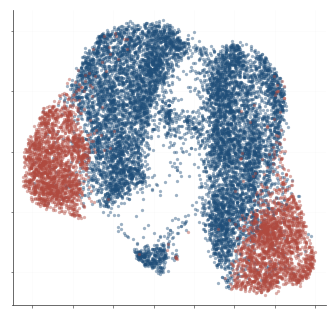

Saved paper-clean panel: umap-overlay-dinov3_vitb-cross-manufacturer-overlay-umap-cosine-paper-l2-singlemarker-nokde-panel-clean.pdf


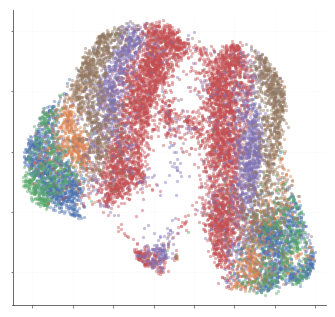

Saved paper-clean panel: umap-overlay-dinov3_vitb-cross-view_position-overlay-umap-cosine-paper-l2-singlemarker-nokde-panel-clean.pdf


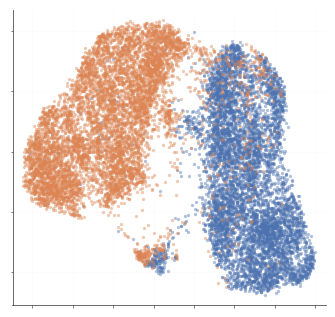

Saved paper-clean panel: umap-overlay-dinov3_vitb-cross-breast_density-overlay-umap-cosine-paper-l2-singlemarker-nokde-panel-clean.pdf


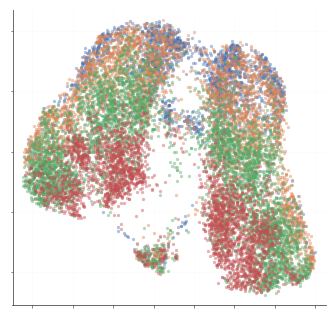

Saved paper-clean panel: umap-overlay-dinov3_vitb-cross-breast_birads-overlay-umap-cosine-paper-l2-singlemarker-nokde-panel-clean.pdf


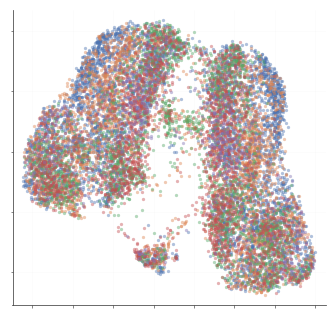

In [6]:
# ---- Paper-clean panel exports for the final 5x5 grid ----
# These panels remove repeated legends, titles, axis labels, and marginal KDEs.
# The optional grid notebook can assemble these panels into the final paper figure
# below each column.
paper_clean_style_tag = f'{plot_style_tag}-panel-clean'
paper_clean_out_dir = inspection_output_root / backbone_key / 'plots' / f'{feature_mode}-{splits_tag}-{paper_clean_style_tag}'
paper_clean_out_dir.mkdir(parents=True, exist_ok=True)
print(f'Paper-clean panel output: {relpath(paper_clean_out_dir)}')

# Smaller/lighter markers keep the dense UMAP panels readable once assembled
# into the paper grid.
paper_panel_point_style = dict(marker='o', s=5.6, alpha=0.44, linewidths=0, zorder=1)


def plot_overlay_umap_paper_panel(attr):
    sub = df_cross[df_cross[attr].notna()].copy()
    if sub.empty:
        raise ValueError(f'No non-null values for {attr}')

    hue_order, palette = hue_style(sub, attr)
    sub = sub.sample(frac=1, random_state=PLOT_RANDOM_SEED)

    fig, ax = plt.subplots(figsize=(3.35, 3.15))
    for label in hue_order:
        part = sub[sub[attr] == label]
        if part.empty:
            continue
        ax.scatter(
            part['UMAP 1'], part['UMAP 2'],
            c=[palette[label]],
            marker=paper_panel_point_style['marker'],
            s=paper_panel_point_style['s'],
            alpha=paper_panel_point_style['alpha'],
            linewidths=paper_panel_point_style['linewidths'],
            zorder=paper_panel_point_style['zorder'],
            rasterized=rasterized_scatter,
        )

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.margins(x=0.035, y=0.035)
    ax.tick_params(
        axis='both', labelbottom=False, labelleft=False,
        bottom=True, left=True, length=1.8, width=0.45, color='0.25'
    )
    ax.grid(alpha=0.10, linewidth=0.38)
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
    ax.spines['left'].set_linewidth(0.55)
    ax.spines['bottom'].set_linewidth(0.55)
    ax.spines['left'].set_color('0.25')
    ax.spines['bottom'].set_color('0.25')

    fig.subplots_adjust(left=0.055, right=0.990, bottom=0.055, top=0.990)
    fname_base = f'umap-overlay-{backbone_key}-cross-{attr_slug(attr)}-{paper_clean_style_tag}'
    pdf_path = paper_clean_out_dir / f'{fname_base}.pdf'
    png_path = paper_clean_out_dir / f'{fname_base}.png'
    fig.savefig(pdf_path, bbox_inches='tight', pad_inches=0.005)
    fig.savefig(png_path, bbox_inches='tight', pad_inches=0.005, dpi=600)
    print(f'Saved paper-clean panel: {pdf_path.name}')
    plt.show()
    plt.close(fig)


paper_clean_attrs = ['Dataset', 'manufacturer_group', 'view_position', 'breast_density', 'breast_birads_display']
for attr in paper_clean_attrs:
    plot_overlay_umap_paper_panel(attr)